绘图成功！文件保存至: global.png


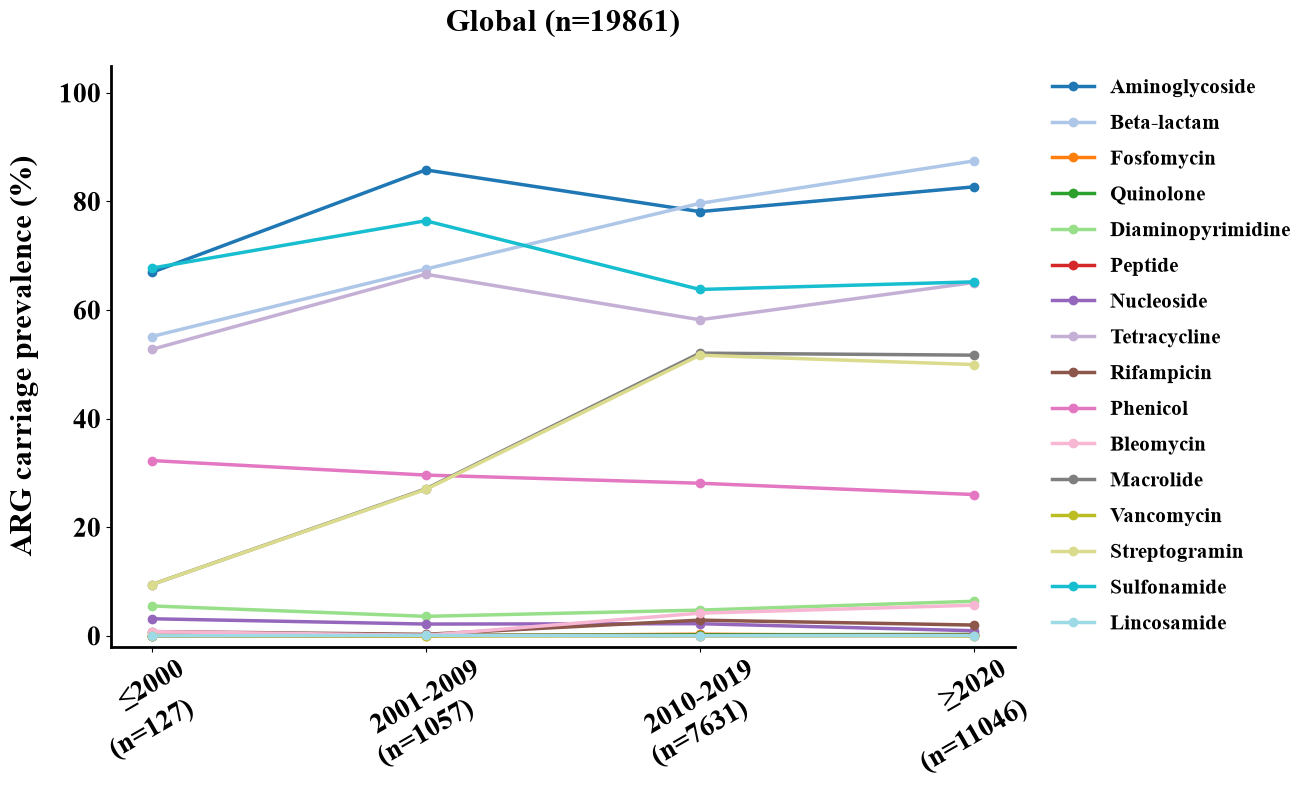

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

# ================= 配置与全局设置 =================

# 设置全局字体为 Times New Roman 并加粗
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

file_path = r'D:\A.baumannii\data\Global_Year.csv'
output_path = 'global.png'

# ================= 1. 数据读取与预处理 =================

try:
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='gbk')


def parse_time_period(x):
    """提取组名和样本总数 N"""
    nums = re.findall(r'\d+', str(x))

    if not nums:
        return x, 1

    n = int(nums[-1])
    last_num_str = nums[-1]
    idx = str(x).rfind(last_num_str)

    group = str(x)[:idx]

    # 清理年份末尾的特殊符号
    group = re.sub(r'[\s\(\[（]+$', '', group)

    return group, n


df['Group'] = df['time_period'].apply(lambda x: parse_time_period(x)[0])
df['N'] = df['time_period'].apply(lambda x: parse_time_period(x)[1])

# 获取抗生素列并转换为百分比
drug_columns = [
    col for col in df.columns
    if col not in ['time_period', 'N', 'Group']
]

for col in drug_columns:
    df[col] = (df[col] / df['N']) * 100


# ================= 2. 绘图区域 =================

fig, ax = plt.subplots(figsize=(12, 8))

# 调色板
colors = plt.cm.tab20(np.linspace(0, 1, len(drug_columns)))

# 绘制折线
for i, col in enumerate(drug_columns):
    ax.plot(
        df['Group'],
        df[col],
        marker='o',
        markersize=6,
        linewidth=2.5,
        label=col,
        color=colors[i]
    )


# ================= 3. 样式精修 =================

# 设置标题
ax.set_title(
    'Global (n=19861)',
    fontsize=22,
    fontweight='bold',
    pad=25
)

# ==================== Y 轴 ====================

# Y轴标题：字体增大
ax.set_ylabel(
    'ARG carriage prevalence (%)',
    fontsize=22,              # 原来是 22，现在改为 26
    fontweight='bold',
    labelpad=15
)

# Y轴刻度数字：字体增大
ax.tick_params(
    axis='y',
    which='major',
    labelsize=20              # 新增：控制Y轴刻度数字大小
)

# 强制 Y 轴刻度为粗体
for label in ax.get_yticklabels():
    label.set_fontfamily('Times New Roman')
    label.set_fontweight('bold')


# ==================== X轴时间段 + 样本量 ====================

x_fontsize = 20
x_rotation = 30
x_pos = np.arange(len(df))

ax.set_xticks(x_pos)

# 时间段
ax.set_xticklabels(
    df['Group'],
    rotation=x_rotation,
    ha='center',
    va='top',
    fontsize=x_fontsize,
    fontfamily='Times New Roman',
    fontweight='bold'
)

# 时间段与横轴保持较小距离
ax.tick_params(
    axis='x',
    which='major',
    pad=4
)

# 样本量：紧跟在时间段下方
for i, n in enumerate(df['N']):
    ax.text(
        i,
        -0.085,
        f'(n={int(n)})',
        transform=ax.get_xaxis_transform(),
        rotation=x_rotation,
        ha='center',
        va='top',
        fontsize=x_fontsize,
        fontfamily='Times New Roman',
        fontweight='bold',
        clip_on=False
    )

# 强制确保 X 轴刻度标签为粗体
for label in ax.get_xticklabels():
    label.set_fontweight('bold')


# ==================== 坐标轴范围与边框 ====================

# 设置 Y 轴范围
ax.set_ylim(-2, 105)

# 隐藏上方和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 加粗剩余边框线
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)


# ==================== 图例 ====================

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    labelspacing=0.8,
    prop={
        'family': 'Times New Roman',
        'weight': 'bold',
        'size': 15
    }
)


# ================= 4. 保存与显示 =================

plt.tight_layout()

# 额外留白，防止右侧图例被切掉
plt.subplots_adjust(right=0.85)

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches='tight'
)

print(f"绘图成功！文件保存至: {output_path}")

plt.show()